### 1. Load key and import libraries

In [3]:
import comtradeapicall
import pandas as pd
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt

load_dotenv()  # Load environment variables from .env file

API_KEY = os.getenv("COMTRADE_API_KEY")

# Confirm it loaded 
print('Key loaded:', API_KEY is not None)

Key loaded: True


### 2. Lookup table for country code

In [4]:
import requests

# Fetch the official reporter codes directly from Comtrade
reporters = requests.get(
    "https://comtradeapi.un.org/files/v1/app/reference/Reporters.json"
).json()["results"]

partners = requests.get(
    "https://comtradeapi.un.org/files/v1/app/reference/partnerAreas.json"
).json()["results"]

# Convert to DataFrames for easy searching
df_reporters = pd.DataFrame(reporters)
df_partners  = pd.DataFrame(partners)

# Search for Malaysia, India, China
print("=== REPORTERS ===")
print(df_reporters[df_reporters["reporterDesc"].str.contains(
    "Malaysia|India|China", case=False, na=False
)][["reporterCode", "reporterDesc"]])

print("\n=== PARTNERS ===")
print(df_partners[df_partners["PartnerDesc"].str.contains(
    "Malaysia|India|China", case=False, na=False
)][["PartnerCode", "PartnerDesc"]])

=== REPORTERS ===
     reporterCode                  reporterDesc
44            156                         China
45            344          China, Hong Kong SAR
46            446              China, Macao SAR
106           699                         India
107           356               India (...1974)
132           458                      Malaysia
173           459  Peninsula Malaysia (...1963)

=== PARTNERS ===
     PartnerCode                              PartnerDesc
36            86                   Br. Indian Ocean Terr.
55           156                                    China
56           344                     China, Hong Kong SAR
57           446                         China, Macao SAR
127          699                                    India
128          356                          India (...1974)
158          458                                 Malaysia
209          459             Peninsula Malaysia (...1963)
247          698  Sikkim, Protectorate of India (...1974)


In [5]:
# Confirmed correct codes
MALAYSIA_CODE = "458"
INDIA_CODE    = "699"    # NOT 356 — that expired in 1974
CHINA_CODE    = "156"

# Test with corrected India code
r = requests.get(
    "https://comtradeapi.un.org/data/v1/get/C/M/HS",
    params={
        "reporterCode":     MALAYSIA_CODE,
        "partnerCode":      CHINA_CODE,
        "cmdCode":          "151110",
        "flowCode":         "X",
        "period":           "202301",
        "subscription-key": API_KEY
    }
)
response_json = r.json()
print("Status:", r.status_code)
print("Count:", response_json.get("count"))
print("Error:", response_json.get("error"))
print("Full response:", response_json)

Status: 200
Count: 0
Error: 
Full response: {'elapsedTime': '0.48 secs', 'count': 0, 'data': [], 'error': ''}


In [6]:
# Test with preview endpoint - no key needed
r_preview = requests.get(
    "https://comtradeapi.un.org/public/v1/preview/C/M/HS",
    params={
        "reporterCode": MALAYSIA_CODE,
        "partnerCode":  CHINA_CODE,
        "cmdCode":      "151110",
        "flowCode":     "X",
        "period":       "202301",
    }
)
print("Preview status:", r_preview.status_code)
print("Preview response:", r_preview.text[:500])

Preview status: 200
Preview response: {"elapsedTime":"0.18 secs","count":0,"data":[],"error":""}


In [7]:
# Check what periods Malaysia has actually reported data for
# Use TOTAL commodity code to see if ANY Malaysia data exists monthly
r_check = requests.get(
    "https://comtradeapi.un.org/public/v1/preview/C/M/HS",
    params={
        "reporterCode": MALAYSIA_CODE,
        "cmdCode":      "TOTAL",
        "flowCode":     "X",
        "partnerCode":  "0",      # 0 = World (all partners)
        "period":       "202301",
    }
)
print("Status:", r_check.status_code)
print("Count:", r_check.json().get("count"))
print("Error:", r_check.json().get("error"))

# Also check annual
r_annual = requests.get(
    "https://comtradeapi.un.org/public/v1/preview/C/A/HS",
    params={
        "reporterCode": MALAYSIA_CODE,
        "cmdCode":      "151110",
        "flowCode":     "X",
        "partnerCode":  INDIA_CODE,
        "period":       "2022",
    }
)
print("\nAnnual check count:", r_annual.json().get("count"))
print("Annual first record:", r_annual.json().get("data", [{}])[:1])

Status: 200
Count: 5
Error: 

Annual check count: 2
Annual first record: [{'typeCode': 'C', 'freqCode': 'A', 'refPeriodId': 20220101, 'refYear': 2022, 'refMonth': 52, 'period': '2022', 'reporterCode': 458, 'reporterISO': None, 'reporterDesc': None, 'flowCode': 'X', 'flowDesc': None, 'partnerCode': 699, 'partnerISO': None, 'partnerDesc': None, 'partner2Code': 0, 'partner2ISO': None, 'partner2Desc': None, 'classificationCode': 'H6', 'classificationSearchCode': 'HS', 'isOriginalClassification': True, 'cmdCode': '151110', 'cmdDesc': None, 'aggrLevel': None, 'isLeaf': None, 'customsCode': 'C00', 'customsDesc': None, 'mosCode': '0', 'motCode': 0, 'motDesc': None, 'qtyUnitCode': 8, 'qtyUnitAbbr': None, 'qty': 2487580000, 'isQtyEstimated': False, 'altQtyUnitCode': 21, 'altQtyUnitAbbr': None, 'altQty': 2487580, 'isAltQtyEstimated': False, 'netWgt': 2487580000, 'isNetWgtEstimated': False, 'grossWgt': 0, 'isGrossWgtEstimated': False, 'cifvalue': None, 'fobvalue': 2975488297.402, 'primaryValue': 2

Malaysia only submits annual data to Comtrade, not monthly. So need to use the annual Comtrade for this panel but reframe the chart slightly \
The chart becomes "annual CPO exports volumes to India vs China" shown as bar chart, with the FX rate from Notebook 02 alongside it as a line

### 3. Pull all years for both countries

In [12]:
import time

def fetch_comtrade_annual(reporter, partner, cmd_code, start_year, end_year):
    """
    Fetch annual Comtrade export data for a reporter-partner-commodity combination.
    Loops year by year to stay within API limits.
    """
    all_records = []
    
    for year in range(start_year, end_year + 1):
        r = requests.get(
            "https://comtradeapi.un.org/data/v1/get/C/A/HS",
            params={
                "reporterCode":     reporter,
                "partnerCode":      partner,
                "cmdCode":          cmd_code,
                "flowCode":         "X",
                "period":           str(year),
                "subscription-key": API_KEY
            }
        )
        
        data = r.json().get("data", [])
        if data:
            all_records.extend(data)
            print(f"  {year}: {len(data)} records")
        else:
            print(f"  {year}: no data")
        
        time.sleep(1)   # be polite — 1 second between calls
    
    return pd.DataFrame(all_records)

print("Fetching Malaysia → India (all palm oil)...")
df_india = fetch_comtrade_annual(
    reporter   = MALAYSIA_CODE,
    partner    = INDIA_CODE,
    cmd_code   = "1511",        # all palm oil, not just crude
    start_year = 2015,
    end_year   = 2025
)

print("\nFetching Malaysia → China (all palm oil)...")
df_china = fetch_comtrade_annual(
    reporter   = MALAYSIA_CODE,
    partner    = CHINA_CODE,
    cmd_code   = "1511",
    start_year = 2015,
    end_year   = 2025
)

print("\nIndia shape:", df_india.shape)
print("China shape:", df_china.shape)

Fetching Malaysia → India (all palm oil)...
  2015: 1 records
  2016: 1 records
  2017: 2 records
  2018: 2 records
  2019: 2 records
  2020: 2 records
  2021: 2 records
  2022: 2 records
  2023: 2 records
  2024: 3 records
  2025: 2 records

Fetching Malaysia → China (all palm oil)...
  2015: 1 records
  2016: 1 records
  2017: 2 records
  2018: 2 records
  2019: 3 records
  2020: 2 records
  2021: 2 records
  2022: 2 records
  2023: 2 records
  2024: 2 records
  2025: 3 records

India shape: (21, 47)
China shape: (22, 47)


### 4. Extract and clean the columns we need

In [17]:
def clean_comtrade(df, destination_label):
    df_clean = df[["period", "qty", "fobvalue"]].copy()
    df_clean = df_clean.rename(columns={
        "period":   "year",
        "qty":      "export_qty_kg",
        "fobvalue": "export_value_usd"
    })
    df_clean["export_qty_tonnes"] = df_clean["export_qty_kg"] / 1000
    df_clean["destination"]       = destination_label
    df_clean["year"]              = df_clean["year"].astype(int)
    df_clean = df_clean[["year", "destination", "export_qty_tonnes", "export_value_usd"]]
    
    # Keep the row with maximum qty per year — not just the first row
    # This correctly handles phantom near-zero duplicates like 2019 and 2025 China
    df_clean = (df_clean
                .sort_values("export_qty_tonnes", ascending=False)
                .drop_duplicates(subset=["year", "destination"])
                .sort_values("year")
                .reset_index(drop=True))
    
    return df_clean

df_india_clean = clean_comtrade(df_india, "India")
df_china_clean = clean_comtrade(df_china, "China")

df_exports = pd.concat([df_india_clean, df_china_clean], ignore_index=True)
df_exports = df_exports.sort_values(["year", "destination"]).reset_index(drop=True)

print(df_exports.to_string())

    year destination  export_qty_tonnes  export_value_usd
0   2015       China       1.840016e+06      1.070030e+09
1   2015       India       3.680207e+06      2.059981e+09
2   2016       China       1.263434e+06      7.963325e+08
3   2016       India       2.795068e+06      1.710824e+09
4   2017       China       1.067260e+06      7.129456e+08
5   2017       India       1.915747e+06      1.297739e+09
6   2018       China       1.118170e+06      6.493819e+08
7   2018       India       2.074386e+06      1.203545e+09
8   2019       China       1.722568e+06      8.978009e+08
9   2019       India       4.136410e+06      2.100137e+09
10  2020       China       1.780830e+06      1.134726e+09
11  2020       India       2.592539e+06      1.694332e+09
12  2021       China       1.144709e+06      1.053893e+09
13  2021       India       3.415722e+06      3.662889e+09
14  2022       China       1.004250e+06      1.153481e+09
15  2022       India       2.870296e+06      3.436707e+09
16  2023      

### 5. Quick plot

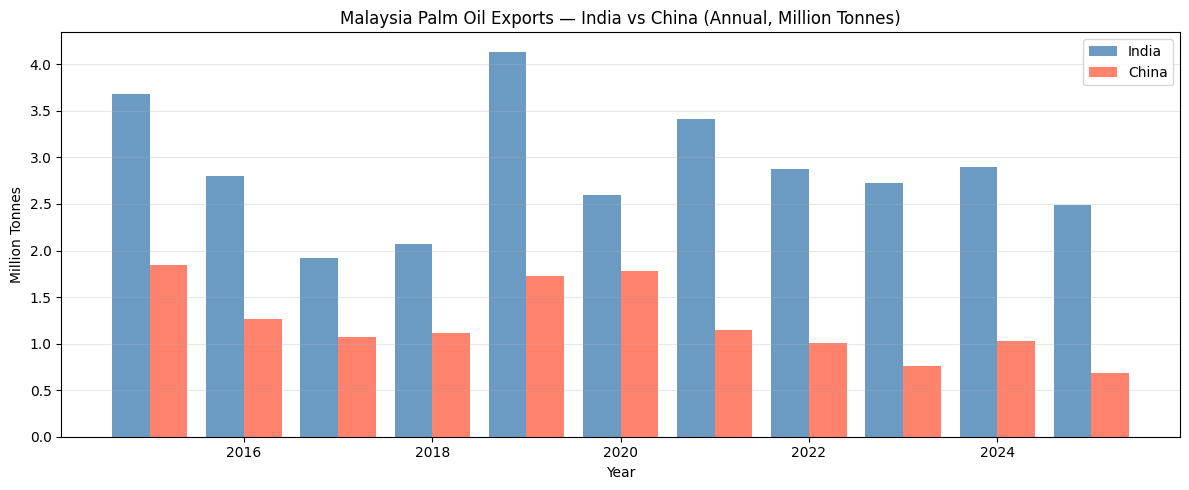

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

for dest, color in [("India", "steelblue"), ("China", "tomato")]:
    subset = df_exports[df_exports["destination"] == dest]
    ax.bar(
        subset["year"] + (0.2 if dest == "China" else -0.2),
        subset["export_qty_tonnes"] / 1e6,
        width=0.4,
        label=dest,
        color=color,
        alpha=0.8
    )

ax.set_title("Malaysia Palm Oil Exports — India vs China (Annual, Million Tonnes)")
ax.set_ylabel("Million Tonnes")
ax.set_xlabel("Year")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Notebook 03 — Findings & Decisions

**Source:** UN Comtrade API
**Library:** comtradeapicall + direct requests to comtradeapi.un.org
**Commodity:** HS 1511 (all palm oil — crude + refined)
**Flow:** Malaysia (reporter) → India + China (partners), Exports only
**Frequency:** Annual only — Malaysia does not submit monthly data to Comtrade

---

### Country Codes — Always Verify, Never Assume

| Country | Code | Note |
|---|---|---|
| Malaysia (reporter) | 458 | Confirmed ✓ |
| India (partner) | 699 | NOT 356 — code 356 = "India (...1974)", expired |
| China (partner) | 156 | Confirmed ✓ |

Codes verified directly from official Comtrade reference files:
- https://comtradeapi.un.org/files/v1/app/reference/Reporters.json
- https://comtradeapi.un.org/files/v1/app/reference/partnerAreas.json

---

### Commodity Code Decision

Initially queried HS `151110` (crude palm oil only).
China volumes returned near-zero — not reflective of real trade.
Root cause: Malaysia exports mostly **refined** palm oil to China,
not crude. India buys both crude and refined.

**Decision:** Broadened to HS `1511` (all palm oil) for both countries
so India and China are compared on the same basis.

---

### Data Quality Issues Found and Fixed

**Issue 1 — Duplicate and aggregate records per year**
Comtrade returns multiple rows per year representing:
- Sub-records (individual shipment classifications)
- An aggregate row that already sums the sub-records

Verified for 2019 China:
- Row A: 8,500 kg (small sub-record)
- Row B: 1,722,560,000 kg (main volume)
- Row C: 1,722,568,000 kg = Row A + Row B (the aggregate)

For 2022 China: two rows are fully identical true duplicates.

Fix: Taking the maximum qty row per year correctly captures the
aggregate total without double-counting. Confirmed by manual inspection.
Do NOT sum rows — this would double-count the aggregate.

**Issue 2 — Phantom near-zero values**
2019 China raw data contained three rows:
- 8.5 tonnes (phantom — unreliable aggregate fragment)
- 1,722,560 tonnes (real trade volume)
- 1,722,568 tonnes (duplicate of real)

2025 China similarly had a 4.56 tonne phantom alongside the real ~679,000
tonne figure. Fixed by keeping max qty row per year as described above.

---

### Data Reliability — Important Caveats

Comtrade trade data should be treated as **directional indicators,
not precise volumes.** Known sources of discrepancy vs other datasets:

- **Mirror statistics:** Malaysia records exports at FOB value (excludes
  freight/insurance). Destination countries record the same shipment at
  CIF value (includes freight/insurance). Difference is typically 10–15%.
- **Re-exports via Singapore:** Some Malaysia → China shipments transit
  Singapore and appear as Malaysia → Singapore, Singapore → China in
  Comtrade — understating direct bilateral flows.
- **Estimation:** Most China records show `isReported=False`,
  `isAggregate=True` — meaning Comtrade estimated these figures, Malaysia
  did not directly submit them.
- **Reporting lag:** Malaysia submits data late. Recent years (2024, 2025)
  may be incomplete or revised later.
- **HS code mapping differences:** Countries sometimes classify the same
  product under slightly different subcodes.

Cross-validation against MPOB total export data is recommended in
Notebook 07. Use Comtrade data for **trend analysis only.**

---

### Final Dataset

**Shape:** 22 rows (11 years × 2 countries)
**Date range:** 2015 – 2025
**Null values:** None

**Columns for pipeline:**

| Column | Type | Description |
|---|---|---|
| year | int | Calendar year |
| destination | str | "India" or "China" |
| export_qty_tonnes | float | Palm oil export volume in tonnes |
| export_value_usd | float | FOB export value in USD |

---

### Key Observations

- India is consistently the largest buyer: 2–4 million tonnes annually,
  roughly 2–3x China volumes every year
- India volumes dropped sharply 2016–2017, recovered from 2019 — likely
  correlated with India's import duty changes on Malaysian palm oil
- China volumes more stable: 0.75–1.84 million tonnes, less policy-driven
- 2025 data present for India (~2.49M tonnes) but China incomplete —
  exclude China 2025 from dashboard until fully reported
- Both countries peaked around 2015 and 2019–2021 — aligns with periods
  of low CPO prices (buyers stock up when prices are attractive)


In [21]:
print(df_china["period"].dtype)
print(df_china["period"].head(10).tolist())

str
['2015', '2016', '2017', '2017', '2018', '2018', '2019', '2019', '2019', '2020']
